# Homework 1
### Grupo 127
#### André Melo (ist1106937) e Gonçalo Aleixo (ist1106900)

## II. Programming [9v]
**Consider the diabetes.arff data available at the homework tab, comprising 8 biological features to**
**classify 768 patients into 2 classes (normal, diabetes).**

**1) [1v] ANOVA is a statistical test that can be used to assess the discriminative power of a**
**single input variable. Using f_classif from sklearn, identify the input variables with the**
**worst and best discriminative power. Plot their class-conditional probability density**
**functions.**

In [19]:
from sklearn.feature_selection import f_classif
from scipy.io.arff import loadarff
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the ARFF file
data = loadarff('diabetes.arff')
df = pd.DataFrame(data[0])

#Decode the 'Outcome' column
df['Outcome'] = df['Outcome'].str.decode('utf-8')

#Separate features(X) from the class(Y)
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

finfo = f_classif(X, Y)  # 0 - discriminative power; 1 - statistical significance;

best_index = finfo[0].argmax()
worst_index = finfo[0].argmin()

best_feature, worst_feature = X.columns[best_index], X.columns[worst_index]

print('Input variable with the highest discriminative power:', best_feature)
print('Input variable with the lowest discriminative power:', worst_feature)

Input variable with the highest discriminative power: Glucose
Input variable with the lowest discriminative power: BloodPressure


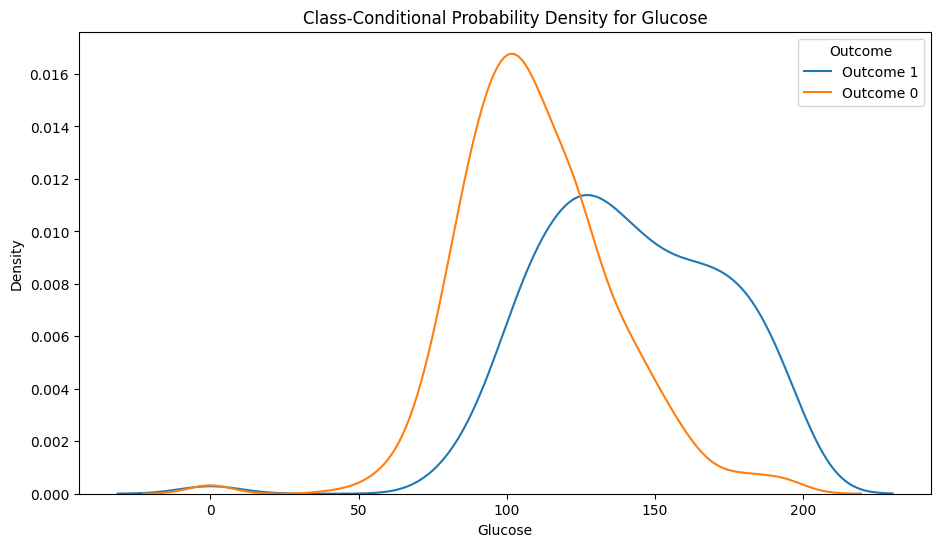

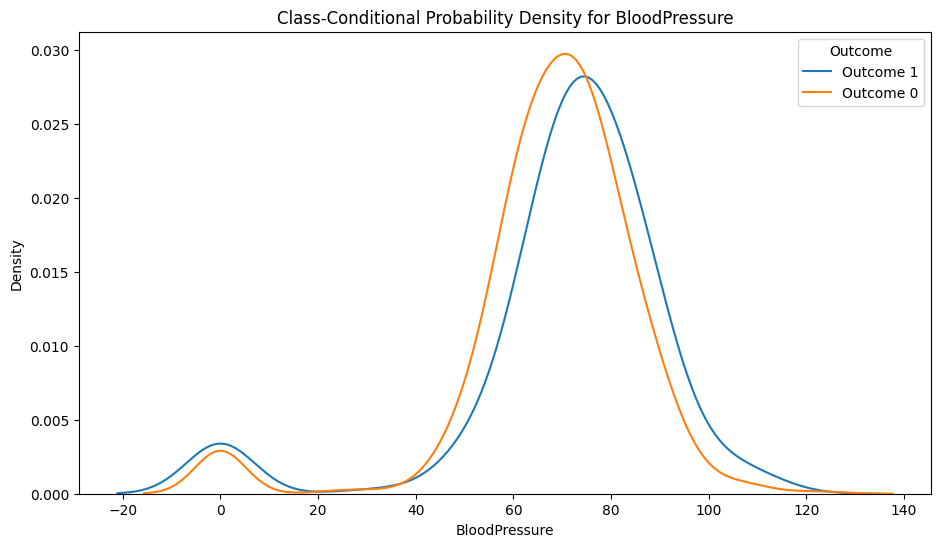

In [20]:
outcomes = df['Outcome'].unique()

#Plot class-conditional probability density function for Glucose
plt.figure(figsize=(11, 6))
for target_outcome in outcomes:
    subset = df[df['Outcome'] == target_outcome]
    sns.kdeplot(subset[best_feature], label=f'Outcome {target_outcome}')
plt.xlabel(best_feature)
plt.ylabel('Density')
plt.title(f'Class-Conditional Probability Density for {best_feature}')
plt.legend(title='Outcome')
plt.show()

#Plot class-conditional probability density function for BloodPreassure
plt.figure(figsize=(11, 6))
for target_outcome in outcomes:
    subset = df[df['Outcome'] == target_outcome]
    sns.kdeplot(subset[worst_feature], label=f'Outcome {target_outcome}')
plt.xlabel(worst_feature)
plt.ylabel('Density')
plt.title(f'Class-Conditional Probability Density for {worst_feature}')
plt.legend(title='Outcome')
plt.show()

**2) [4v] Using a stratified 80-20 training-testing split with a fixed seed (random_state=1), assess**
**in a single plot both the training and testing accuracies of a decision tree with minimum**
**sample split in {2, 5,10, 20, 30, 50, 100} and the remaining parameters as default.**

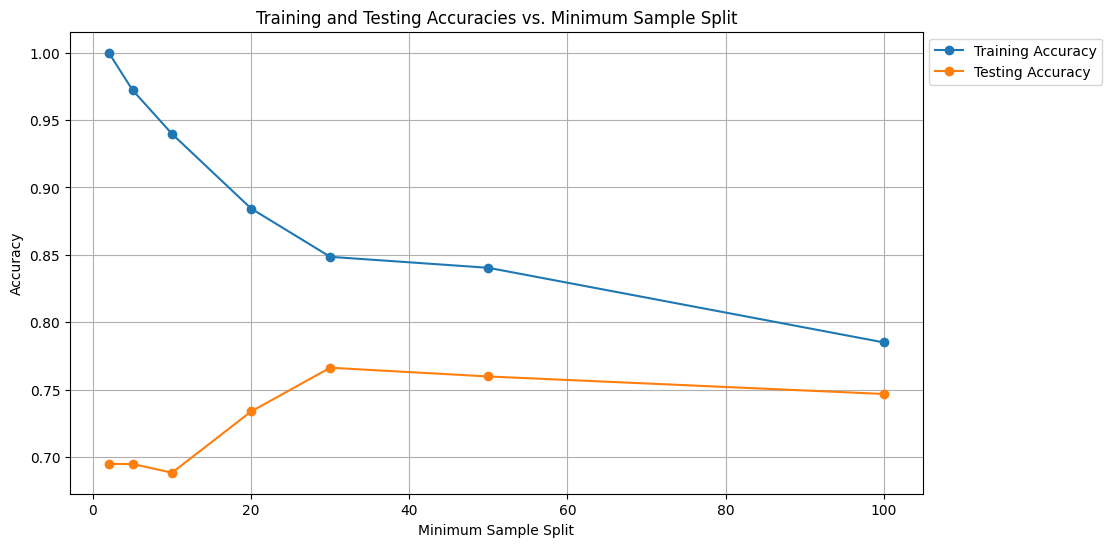

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from scipy.io.arff import loadarff
import pandas as pd

#Load the ARFF file
data = loadarff('diabetes.arff')
df = pd.DataFrame(data[0])

#Decode the 'Outcome' column
df['Outcome'] = df['Outcome'].str.decode('utf-8')

#Separate features(X) from the class(Y)
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

min_samples_split = [2, 5, 10, 20, 30, 50, 100]

# Split the dataset into a training set (80%) and a testing set (20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state = 1, stratify=y)

training_accuracies = []
testing_accuracies = []

for min_samples in min_samples_split:
    # Train the Decision Tree with specified min_samples_split
    predictor = DecisionTreeClassifier(min_samples_split=min_samples, random_state=1)
    predictor.fit(X_train, Y_train)

    # Predictions on training and testing sets
    Y_train_pred = predictor.predict(X_train)
    Y_test_pred = predictor.predict(X_test)
    
    # Calculate and store accuracies
    training_accuracies.append(accuracy_score(Y_train, Y_train_pred))
    testing_accuracies.append(accuracy_score(Y_test, Y_test_pred))

#Plot
plt.figure(figsize=(11, 6))
plt.plot(min_samples_split, training_accuracies, label='Training Accuracy', marker='o')
plt.plot(min_samples_split, testing_accuracies, label='Testing Accuracy', marker='o')
plt.xlabel('Minimum Sample Split')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracies vs. Minimum Sample Split')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

**3) [2v] Critically analyze these results, including the generalization capacity across settings.**

Analisando os resultados de training accuracy, vemos que ela começa muito alta quando o parâmetro min_samples_split é pequeno. O que faz sentido, porque a árvore de decisão pode crescer mais e ajustar-se mais aos dados de treinamento, o que resulta numa precisão quase perfeita. Mas, conforme esse valor vai aumentando, a training accuracy diminui. Isso acontece porque a árvore fica mais "preguiçosa" ao fazer divisões, e torna-se menos complexa e menos ajustada aos dados de treino, o que reduz o desempenho.

Agora, olhando para a testing accuracy, o comportamento é um pouco diferente. Ela começa baixa e melhora quando o min_samples_split aumenta, o que sugere que o modelo tá generalizando melhor. Mas a partir de um certo ponto (em torno de 30 a 50), a testing accuracy começa a estabilizar e a cair levemente. Isso indica que o modelo tá ficando muito simples, ou seja, está sofrendo de underfitting — não está capturando bem os padrões dos dados.

Resumindo, o gráfico mostra que a árvore de decisão, com valores baixos de min_samples_split, sofre de overfitting, porque se ajusta muito bem aos dados de treinamento, mas não generaliza bem para os dados de teste. Conforme o valor de min_samples_split vai aumentando, o modelo vai melhorando sua capacidade de generalização, até atingir um ponto de equilíbrio. A partir desse ponto, aumentar o parâmetro só prejudica a performance geral, levando a um modelo que não consegue capturar a complexidade dos dados, sofrendo de underfitting.

O ponto ideal de generalização parece ser em torno de um min_samples_split entre 30 e 50, onde o desempenho nos dados de teste é relativamente estável e não há uma grande queda, o que demonstra que o modelo está equilibrando bem a complexidade e a capacidade de generalização.

**4) [2v] To deploy the predictor, a healthcare provider opted to learn a single decision tree**
**(random_state=1) using all available data and ensuring that the maximum depth would be 3**
**in order to avoid overfitting risks.**

**i. Plot the decision tree.**

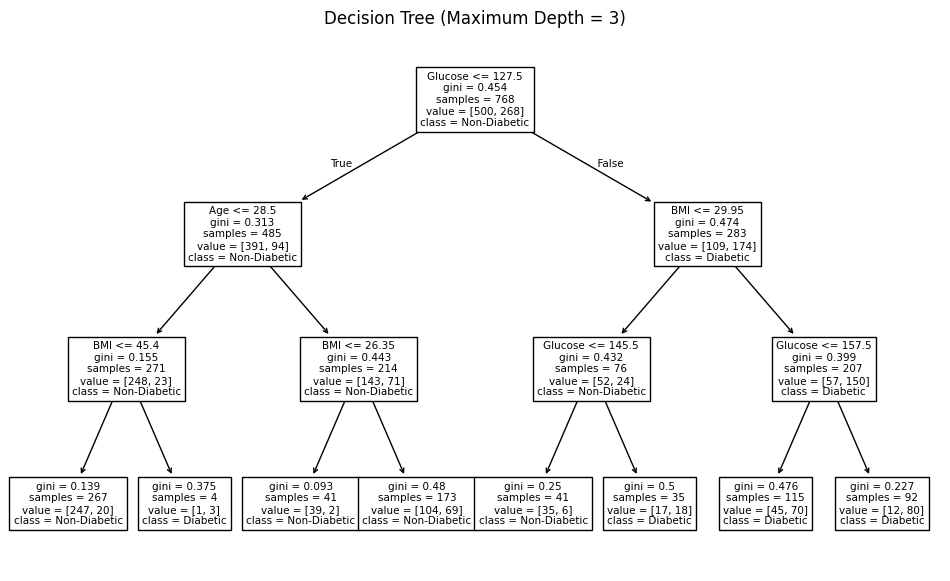

In [82]:
from scipy.io.arff import loadarff
import pandas as pd
from sklearn.tree import plot_tree, DecisionTreeClassifier
import matplotlib.pyplot as plt

#Load the ARFF file
data = loadarff('diabetes.arff')
df = pd.DataFrame(data[0])

#Decode the 'Outcome' column
df['Outcome'] = df['Outcome'].str.decode('utf-8')

#Separate features(X) from the class(Y)
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

# learn classifier
predictor = DecisionTreeClassifier(max_depth=3, random_state=1)
predictor.fit(X, Y)

figure = plt.figure(figsize=(12, 7))
plot_tree(predictor, feature_names=X.columns, class_names=['Non-Diabetic', 'Diabetic'])
plt.title("Decision Tree (Maximum Depth = 3)")

plt.show()

**ii. Explain what characterizes diabetes by identifying the conditional associations**
**together with their posterior probabilities.**

- Se os níveis de glicose forem maiores que 127.5, automaticamente, o indivíduo tem $\frac{174}{283}$≈61.5% de ter diabetes.
- Se os níveis de glicose forem maiores que 127.5 e se o BMI for maior que 29.95, então o indivíduo tem $\frac{150}{207}$≈72.5% de ter diabetes. Por outro lado, se o BMI for menor que 29.95 mas os níveis de glicose forem maiores que 145.5 o indivíduo tem $\frac{18}{35}$≈51.4% de ter diabetes.
- Se os níveis de glicose forem menores que 127.5, a sua idade for menor que 28.5 e o BMI for maior que 45.4 o indivíduo tem $\frac{3}{4}$≈75% de ter diabetes.